In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

In [2]:
df = pd.read_csv("Fifa_players.csv")
df

,wage_eur,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,320000.0,34.0,170.0,72.0,b'Argentina',93.0,93.0,85.0,95.0,70.0,...,91.0,94.0,95.0,35.0,24.0,6.0,11.0,15.0,14.0,8.0
1,270000.0,32.0,185.0,81.0,b'Poland',92.0,92.0,71.0,95.0,90.0,...,77.0,93.0,82.0,42.0,19.0,15.0,6.0,12.0,8.0,10.0
2,270000.0,36.0,187.0,83.0,b'Portugal',91.0,91.0,87.0,95.0,90.0,...,86.0,94.0,74.0,32.0,24.0,7.0,11.0,15.0,14.0,11.0
3,270000.0,29.0,175.0,68.0,b'Brazil',91.0,91.0,85.0,83.0,63.0,...,96.0,89.0,84.0,32.0,29.0,9.0,9.0,15.0,15.0,11.0
4,350000.0,30.0,181.0,70.0,b'Belgium',91.0,91.0,94.0,82.0,55.0,...,79.0,91.0,78.0,65.0,53.0,15.0,13.0,5.0,10.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,1000.0,22.0,180.0,64.0,b'China PR',47.0,52.0,46.0,32.0,48.0,...,55.0,53.0,70.0,43.0,48.0,6.0,10.0,5.0,15.0,13.0
19174,500.0,19.0,175.0,70.0,b'Republic of Ireland',47.0,59.0,54.0,33.0,46.0,...,64.0,49.0,69.0,44.0,47.0,11.0,12.0,6.0,8.0,10.0
19175,500.0,21.0,178.0,72.0,b'Republic of Ireland',47.0,55.0,39.0,32.0,43.0,...,58.0,46.0,59.0,44.0,48.0,8.0,6.0,7.0,10.0,6.0
19176,500.0,19.0,173.0,66.0,b'Republic of Ireland',47.0,60.0,29.0,49.0,40.0,...,72.0,48.0,73.0,14.0,11.0,7.0,10.0,7.0,14.0,15.0


In [3]:
##Question 1
data1 = df[["age", "overall", "wage_eur"]].copy()

data1 = data1.dropna()

X = data1[["age", "overall"]]
y = data1["wage_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=1)

model1 = RandomForestRegressor(n_estimators=100)
model1.fit(X_train, y_train)

predictions = model1.predict(X_test)

print("Q1 Results:")
print("R^2 Score:", r2_score(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))

Q1 Results:
R^2 Score: 0.737101685857791
RMSE: 9962.127063230522



Q2 Results:
count    19178.000000
mean         5.316196
std          5.517778
min          0.000000
25%          0.000000
50%          4.000000
75%          9.000000
max         26.000000
Name: growth, dtype: float64
Explained Variance: [0.61347321 0.27489789]


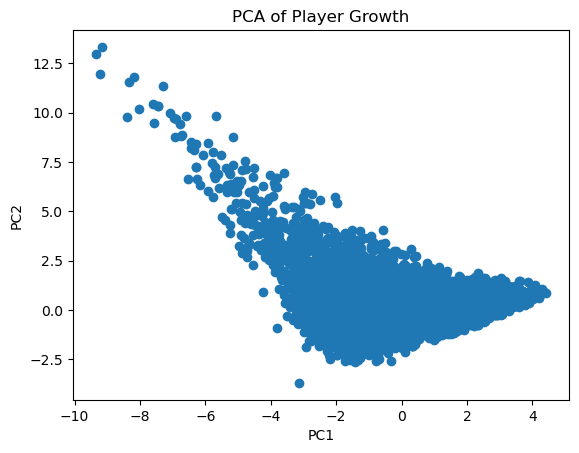

In [4]:
##Question 2
df["growth"] = df["potential"] - df["overall"]

data2 = df[["age", "overall", "wage_eur", "growth"]].copy()

data2 = data2.dropna()

print("\nQ2 Results:")
print(data2["growth"].describe())

scaler = StandardScaler()
scaled = scaler.fit_transform(data2)

pca = PCA(n_components=2)
result = pca.fit_transform(scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

plt.scatter(result[:, 0], result[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Player Growth")
plt.show()

In [5]:
##Question 3
df["potential_level"] = np.where(df["potential"] >= 85, 1, 0)

data3 = df[["age", "overall", "wage_eur", "potential_level"]].copy()

data3 = data3.dropna()

X = data3[["age", "overall", "wage_eur"]]
y = data3["potential_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=1)

model3 = RandomForestClassifier(n_estimators=100)
model3.fit(X_train, y_train)

predictions = model3.predict(X_test)

print("\nQ3 Results:")
print("Accuracy:", accuracy_score(y_test, predictions))


Q3 Results:
Accuracy: 0.9907890163364615
